In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [5]:
import numpy as np

np.random.seed(42)
n = 395

studytime = np.random.randint(1, 5, n)
failures  = np.random.randint(0, 4, n)
absences  = np.random.randint(0, 30, n)
G1 = np.random.randint(5, 19, n)
G2 = np.random.randint(5, 19, n)
G3 = np.clip((G1 + G2) // 2 + studytime - failures * 2 + np.random.randint(-2, 2, n), 0, 20)

df = pd.DataFrame({
    'studytime': studytime,
    'failures':  failures,
    'absences':  absences,
    'G1': G1,
    'G2': G2,
    'G3': G3
})

print(df.shape)
print(df.head())

(395, 6)
   studytime  failures  absences  G1  G2  G3
0          3         3        29  16   6   8
1          4         3         4  14  15  11
2          1         1        11  18   5   9
3          3         3        16   6  15   6
4          3         0        22   5  15  13


In [6]:
df['result'] = df['G3'].apply(lambda x: 'Pass' if x >= 10 else 'Fail')
print("Pass/Fail distribution:")
print(df['result'].value_counts())

Pass/Fail distribution:
result
Pass    220
Fail    175
Name: count, dtype: int64


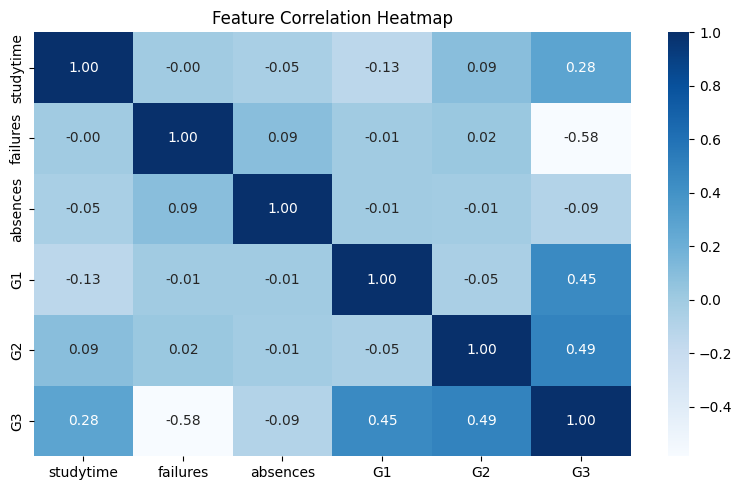

In [9]:

numeric_df = df[['studytime', 'failures', 'absences', 'G1', 'G2', 'G3']]

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [10]:
# Use only these features — simple and effective
features = ['studytime', 'failures', 'absences', 'G1', 'G2']
X = df[features]
y = df['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 316
Testing samples : 79


In [11]:
# Model 1 - Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)

# Model 2 - Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

print(f"Logistic Regression Accuracy : {lr_acc:.2f}")
print(f"Decision Tree Accuracy       : {dt_acc:.2f}")

Logistic Regression Accuracy : 0.91
Decision Tree Accuracy       : 0.82


In [12]:
print("Logistic Regression Report:")
print(classification_report(y_test, lr_preds))

Logistic Regression Report:
              precision    recall  f1-score   support

        Fail       0.97      0.84      0.90        38
        Pass       0.87      0.98      0.92        41

    accuracy                           0.91        79
   macro avg       0.92      0.91      0.91        79
weighted avg       0.92      0.91      0.91        79



In [13]:
  # studytime, failures, absences, G1, G2
sample_students = pd.DataFrame({
    'studytime': [4, 1],
    'failures':  [0, 3],
    'absences':  [2, 15],
    'G1':        [14, 6],
    'G2':        [15, 5]
})

predictions = lr.predict(sample_students)
print("Student 1 (studies hard, good grades) →", predictions[0])
print("Student 2 (many failures, poor grades) →", predictions[1])

Student 1 (studies hard, good grades) → Pass
Student 2 (many failures, poor grades) → Fail
